In [1]:
# 3. 막대그래프

In [2]:
# 막대그래프 bar chart는 데이터의 크기를 막대의 길이로 표현한 그래프
# 성별 소득 차이처럼 집단 간 차이를 표현할 때 사용

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.ma.extras import unique

In [4]:
df = pd.read_csv('./input/mpg.csv')
df.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


In [5]:
# 자동차 연비 관련 데이터셋
# manufacturer : 자동차 제조사
# model : 자동차 모델명
# displ : 배기량 (리터 단위)
# year : 제조년도
# cyl : 실린더 개수
# trans : 변속시 유형 (auto=자동, manual=수동)
# drv : 구동방식 (f=전륜, r=후륜, 4=4륜)
# cty : 도시 연비
# hwy : 고속도로 연비
# fl : 연료 유형 (e.g., p=Premium, r=Regular)
# category : 차량 유형 (compact, suv, midsize 등)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   manufacturer  234 non-null    object 
 1   model         234 non-null    object 
 2   displ         234 non-null    float64
 3   year          234 non-null    int64  
 4   cyl           234 non-null    int64  
 5   trans         234 non-null    object 
 6   drv           234 non-null    object 
 7   cty           234 non-null    int64  
 8   hwy           234 non-null    int64  
 9   fl            234 non-null    object 
 10  category      234 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 20.2+ KB


In [7]:
df.isnull().sum()

manufacturer    0
model           0
displ           0
year            0
cyl             0
trans           0
drv             0
cty             0
hwy             0
fl              0
category        0
dtype: int64

In [8]:
df.describe()

,displ,year,cyl,cty,hwy
count,234.000000,234.000000,234.000000,234.000000,234.000000
mean,3.471795,2003.500000,5.888889,16.858974,23.440171
std,1.291959,4.509646,1.611534,4.255946,5.954643
min,1.600000,1999.000000,4.000000,9.000000,12.000000
25%,2.400000,1999.000000,4.000000,14.000000,18.000000
50%,3.300000,2003.500000,6.000000,17.000000,24.000000
75%,4.600000,2008.000000,8.000000,19.000000,27.000000
max,7.000000,2008.000000,8.000000,35.000000,44.000000


In [9]:
df['manufacturer'].value_counts()

manufacturer
dodge         37
toyota        34
volkswagen    27
ford          25
chevrolet     19
audi          18
hyundai       14
subaru        14
nissan        13
honda          9
jeep           8
pontiac        5
land rover     4
mercury        4
lincoln        3
Name: count, dtype: int64

In [10]:
df['manufacturer'].unique()

array(['audi', 'chevrolet', 'dodge', 'ford', 'honda', 'hyundai', 'jeep',
       'land rover', 'lincoln', 'mercury', 'nissan', 'pontiac', 'subaru',
       'toyota', 'volkswagen'], dtype=object)

In [11]:
# 1. 평균 막대 그래프 만들기

# 평균 막대 그래프는 평균값의 크기를 막대 길이로 표현한 그래프
# 여러 집단의 편균 값을 비교할 때 평균 막대 그래프를 주로 사용

In [12]:
# 1) 집단별 평균표 만들기
#
# 평균 막대 그래프를 만들려면 집단별 평균값을 담은 데이터 프레임이 필요
# '구동 방식별 고속도로 연비 평균'을 담은 데이터 프레임을 만듬
# drv별로 분리하고 hwy 평균 구하기
#
# agg(mean_hwy=('hwy', 'mean') -> mean_hwy열을 생성하면서 'hwy'열의 평균값을 입력)

In [13]:
df['drv'].value_counts()

drv
f    106
4    103
r     25
Name: count, dtype: int64

In [16]:
# mpg 데이터에서 drv(구동방식)별 hwy(고속도로 연비) 평균을 나다낸 막대 그래프를 만듦
df_mpg = df.groupby('drv').agg(mean_hwy=('hwy', 'mean')) # agg = aggregate :집합하다 (단순한 집계 연산에 사용)
df_mpg

,mean_hwy
drv,
4,19.174757
f,28.160377
r,21.000000


In [17]:
# 출력 결과를 보면 집단을 나타낸 변수 drv가 인덱스로 바뀌어 mean_hwy 아래에 표시
# seaborn으로 그래프를 만들려면 값이 변수(컬럼)에 담겨 있어야 함
# -> 인덱스가 아니라 열로 만들어져야 함
# 변수를 인덱스로 바꾸지 않고 원래대로 유지하려면 df.groupby()에 as_index = False를 입력

In [18]:
df_mpg = df.groupby('drv', as_index=False).agg(mean_hwy=('hwy', 'mean'))
df_mpg

,drv,mean_hwy
0,4,19.174757
1,f,28.160377
2,r,21.000000


In [19]:
# 2) 그래프 만들기
#
# 생성된 데이터 프레임을 이용해 막대 그래프를 만듦
# sns.barplot() : 막대 그래프를 만들 때 사용
# x : x축에 범주를 나타낸 변수
# y : y축에 평균값을 나타낸 변수

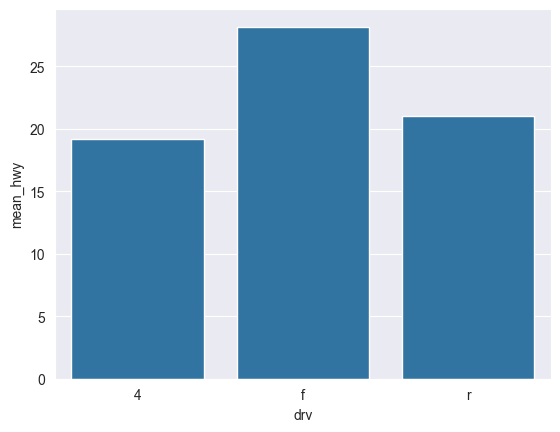

In [20]:
sns.barplot(data=df_mpg, x='drv', y='mean_hwy')
plt.show()

In [21]:
# 3) 크기순으로 정렬하기
#
# 막대 정렬 순서는 그래프를 만드는데 사용한 데이터 프레임의 행 순서에 따라 정해짐
# 앞에서 풀력한 그래프를 보면 drv 막대가 4, f, r 순으로 정렬
# 크기 순으로 정렬하려면 그래프를 만들기 전에 df.sort_values()를 이용해 데이터 프레임을 내림차순으로 정렬

In [22]:
df_mpg = df_mpg.sort_values(by=['mean_hwy'], ascending=False)
df_mpg

,drv,mean_hwy
1,f,28.160377
2,r,21.000000
0,4,19.174757


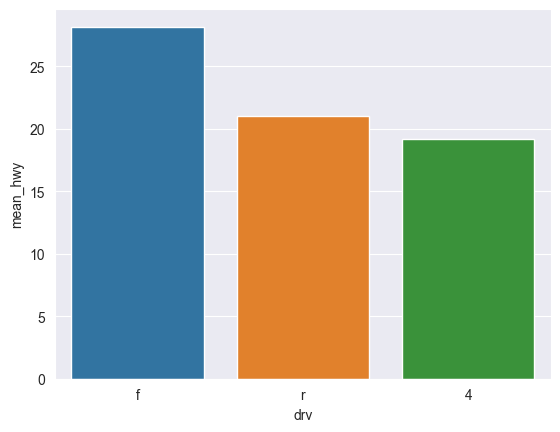

In [24]:
sns.barplot(data=df_mpg, x='drv', y='mean_hwy', hue='drv')
plt.show()

In [25]:
# 2. 빈도 막대 그래프 만들기
#
# 빈도 막대 그래프는 값의 빈도(개수)를 막대 길이로 표현한 그래프
# 여러 집단의 빈도를 비교할 때 빈도 막대 그래프를 자주 사용

In [26]:
# 1) 집단별 빈도표 만들기

# 빈도 막대 그래프를 만들려면 집단별 빈도를 담은 데이터 프레임이 필요
# df.agg()에 빈도를 구하는 함수 count를 적용해 '구동방식 별 빈도'를 담은 데이터 프레임을 만듦

In [27]:
df_mpg = df.groupby('drv', as_index=False).agg(count_hwy=('hwy', 'count'))
df_mpg

,drv,count_hwy
0,4,103
1,f,106
2,r,25


In [28]:
# 2) 그래프 만들기
# sns.barplot()을 적용해 막대 그래프 만듦

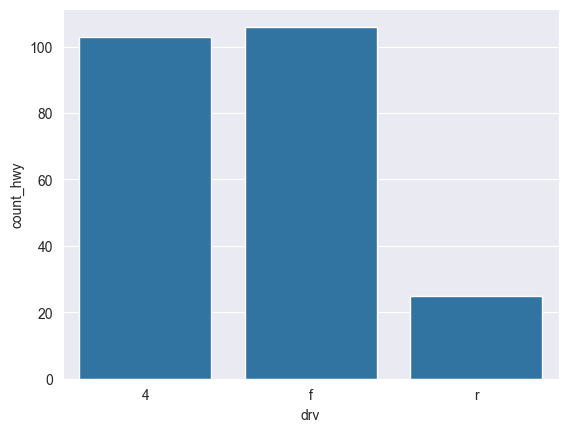

In [29]:
sns.barplot(data=df_mpg, x='drv', y='count_hwy')
plt.show()

In [30]:
# sns.barplot() 사용할 때 df.groupby()와 df.agg()를 이용해 집단별 빈도표를 만드는 작업 했음
# 대신, sns.countplot()을 이용하면 원데이터를 바로 이용해 빈도 막대 그래프를 만들 수 있음

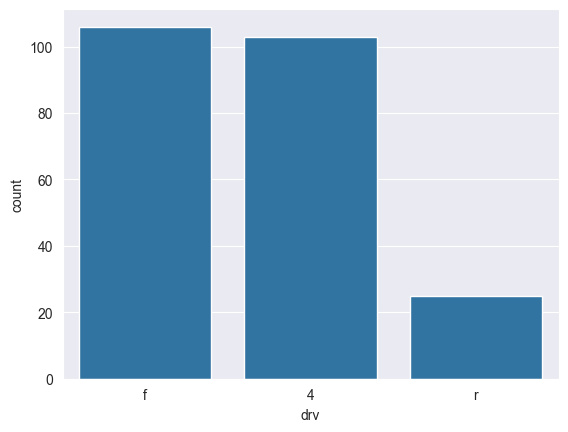

In [32]:
sns.countplot(data=df, x='drv')
plt.show()

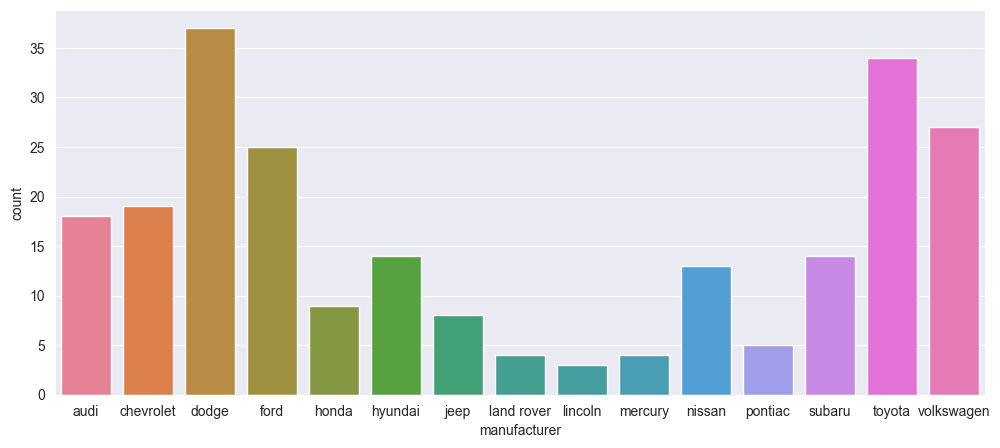

In [36]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='manufacturer', hue='manufacturer')
plt.show()

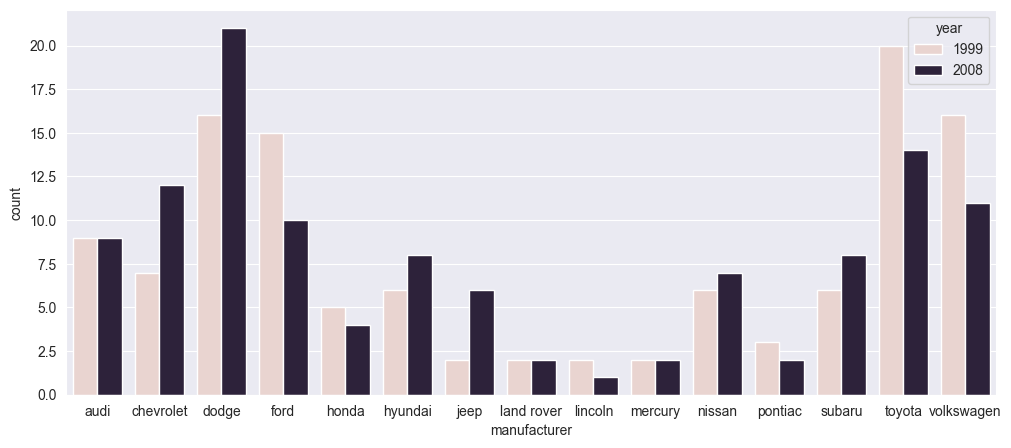

In [38]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='manufacturer', hue='year')
plt.show()

In [39]:
df.value_counts('year')

year
1999    117
2008    117
Name: count, dtype: int64

In [40]:
# 두 그래프는 x축의 순서가 다름
# sns.barplot()으로 만든 그래프는 x축 순서가 4, f, r,인 반면
# sns.countplot()로 만든 그래프는 f, 4, r
# 이는 sns.barplot()에 사용한 df_mpg와 sns.countplot()에 사용한 df의 drv 값 순서가 다르기 때문

In [42]:
# 데이터 프레임에서 변수의 값 순서는 데이터 프레임에 입력된 행의 순서에 따름
# mpg의 drv는 0~6행이 7~17행이 4, 18~27이 r로 되어 있으므로 값의 순서는 f, 4, r
# 변수의 고유값을 출력하는 unique()를 이용하면 값의 순서를 알 수 있음
df['drv'].unique()

array(['f', '4', 'r'], dtype=object)

In [43]:
# df_mpg의 drv는 값의 순서가 알파벳 순으로 되어 있음
# groupby()를 이용해 데이터 프레임을 요약하면 값의 순서가 알파벳순으로 바뀌기 때문
df_mpg['drv'].unique()

array(['4', 'f', 'r'], dtype=object)

In [44]:
# 3) 막대 정렬하기

# sns.countplot()으로 만든 그래프의 막대를 정렬하려면 order에 원하는 순서로 값을 입력하면 됨

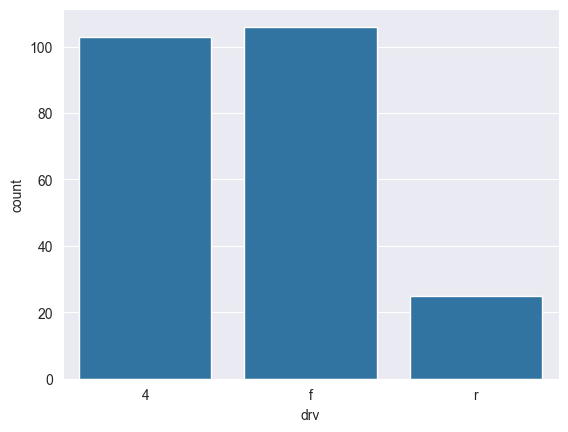

In [45]:
# 4, f, r 순으로 막대 정렬
sns.countplot(data=df, x='drv', order=['4', 'f', 'r'])
plt.show()

In [46]:
# sns.countplot()의 order에 df['drv'].value_counts().index를 입력하면
# drv의 빈도가 높은 순으로 막대를 정렬
# df['drv'].value_counts().index는 빈도가 높은 순으로 변수의 값을 출력

In [47]:
# drv의 값을 빈도가 높은 순으로 출력
df['drv'].value_counts().index

Index(['f', '4', 'r'], dtype='object', name='drv')

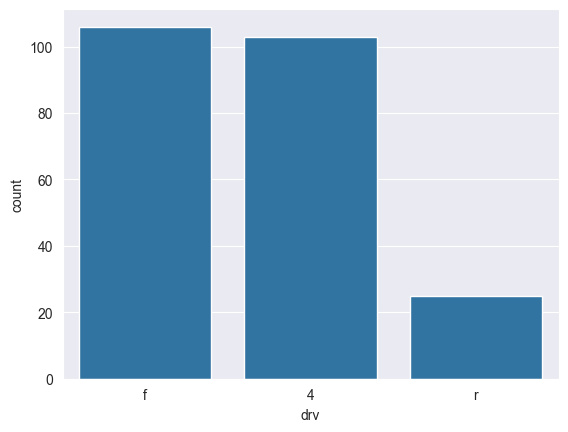

In [48]:
sns.countplot(data=df, x='drv', order=df['drv'].value_counts().index)
plt.show()